# YOLO26 vs YOLO11 on VisDrone

**Deep Learning — Final Project**

**Paper:** *Ultralytics YOLO26: Unified Real-Time End-to-End Vision Models* — Ultralytics, arXiv, June 2026

**Group members**

| Name | ID |
|---|---|
| David Goldzweig | 342745767 |
| Tomer Goldstein | 207797234 |
| Neta Barnoor | 322852146 |

Testing four claims from the paper on a domain it does not cover: aerial drone imagery
with small, dense objects.

# Guidelines

  ### 1. Pick your data source before you run anything

  `DATA_SOURCE` in Part 0 decides what every table below is built from:

  | value | what the tables show |
  |---|---|
  | `'original'` | the run the slideshow was built from (2026-09-02) |
  | `'new'` | today's measurements |

  Either way **every cell still measures**. Only the latency columns are affected — mAP,
  recall, box counts and all 13 bootstrap intervals are deterministic and come out
  identical in both modes.

  ### 2. What Part 8 does with that choice

  On `'original'` it prints one set of tables. On `'new'` it prints the original alongside
  the new one, with the numeric difference between them.

  ### 3. No training needed

  The trained checkpoints are in the repo's `weights/` folder and cell 0.4b downloads them
  (~11 MB). Skip Part 1.

  ### 4. Rounding

  Half *away from zero*, matching the slideshow. Python's default rounds half to even, so
  `0.825` would otherwise print as `0.82` instead of `0.83`.

  ### 5. Map of the notebook

  | Part | Produces |
  |---|---|
  | 0 | Setup, data source, rounding |
  | 1 | Training — **not needed**, checkpoints come from the repo |
  | 2 | Evaluation and statistics — shared by every slide below |
  | 3 | Slide 9 — Result 1, each model in its native recipe |
  | 4 | Slide 10 — Per-class breakdown |
  | 5 | Slide 11 — Qualitative comparison |
  | 6 | Slide 12 — Result 2, NMS-free vs NMS |
  | 7 | Slide 13 — Result 3, the CPU speed claim |
  | 8 | Summary, and the original-vs-new comparison |

## Part 0 - Setup

### 0 · Runtime check
Confirms the machine. Needs an **L4 with 12 vCPUs**.

In [1]:
import psutil, os
print('vCPUs:', os.cpu_count())
print('RAM:  %.1f GB' % (psutil.virtual_memory().total / 1e9))
!nvidia-smi --query-gpu=name --format=csv,noheader

vCPUs: 12
RAM:  56.9 GB
NVIDIA L4


###0.1 · Ultralytics version

In [32]:
# Pin Ultralytics to the version the slideshow was produced with.
# 8.4.145 is what the original run used (verified from the v5 notebook's logs).
ULTRA_PIN = '8.4.145'          # None = whatever pip resolves today

!pip install -q ultralytics{'==' + ULTRA_PIN if ULTRA_PIN else ''} pycocotools faster-coco-eval

import ultralytics
from ultralytics import YOLO
print('ultralytics', ultralytics.__version__)
assert ULTRA_PIN is None or ultralytics.__version__ == ULTRA_PIN, \
    (f'pinned {ULTRA_PIN} but running {ultralytics.__version__} -- '
     'Runtime > Restart session, then run this cell again.')

ultralytics 8.4.145


### 0.2 · Mount Drive
All outputs go to Drive, so a disconnect costs nothing.

In [3]:
# Mount Drive so checkpoints survive a Colab disconnect.
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/dl_final_project_yolo26'
else:
    PROJECT_DIR = '/content/runs'

import os
os.makedirs(PROJECT_DIR, exist_ok=True)
print('Runs will be saved under:', PROJECT_DIR)

Mounted at /content/drive
Runs will be saved under: /content/drive/MyDrive/dl_final_project_yolo26


### 0.3 · Constants

- **`MAX_DET = 317`:** VisDrone's densest image has 317 objects, exceeding Ultralytics' default limit of 300. Setting this explicitly aligns the Validator and `pycocotools`.
- **`P_FLOOR = 2/B`:** For $B = 1000$ bootstrap resamples, the minimum resolvable p-value is 0.002. A output of `p = 0.0000` indicates no resample crossed zero, not $p < 0.001$.
- **`SHORT`:** Provides compact labels for each configuration to keep comparison tables neatly aligned.

In [4]:
# Shared hyperparameters -- identical for both models.
# The ONLY intentional difference between the two training runs is the optimizer.
import os, glob
import numpy as np
import pandas as pd
from ultralytics.utils import SETTINGS

DATA     = 'VisDrone.yaml'   # built into Ultralytics; auto-downloads (~2GB) on first use
EPOCHS   = 60
IMGSZ    = 640
BATCH    = 16
SEED     = 0
PATIENCE = 20

RUN26 = 'yolo26n_visdrone_musgd'
RUN11 = 'yolo11n_visdrone_sgd'
W26   = f'{PROJECT_DIR}/{RUN26}/weights/best.pt'
W11   = f'{PROJECT_DIR}/{RUN11}/weights/best.pt'

# --- evaluation constants, shared by every cell below ---------------------
VAL_DIR = f'{PROJECT_DIR}/val'   # each val run writes VAL_DIR/<tag>/predictions.json
MAX_DET = 317                    # VisDrone val's densest image holds 317 objects
B       = 1000                   # bootstrap replicates
P_FLOOR = 2 / B                  # smallest p-value B replicates can resolve
KEYS    = ('preprocess', 'inference', 'postprocess')

root  = f"{SETTINGS['datasets_dir']}/VisDrone"
NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck',
         'tricycle', 'awning-tricycle', 'bus', 'motor']

CFG26_NMS = 'YOLO26n (one-to-many + NMS)'
CFG26_E2E = 'YOLO26n (end-to-end, NMS-free)'
CFG11     = 'YOLO11n (NMS)'
SHORT     = {CFG26_NMS: 'YOLO26n + NMS',
             CFG26_E2E: 'YOLO26n e2e',
             CFG11:     'YOLO11n + NMS'}

M26, M11 = 'YOLO26n + NMS', 'YOLO11n + NMS'   # CPU table row names

print(f'weights   {W26}')
print(f'          {W11}')
print(f'val runs  {VAL_DIR}/<tag>/predictions.json   (max_det={MAX_DET})')

weights   /content/drive/MyDrive/dl_final_project_yolo26/yolo26n_visdrone_musgd/weights/best.pt
          /content/drive/MyDrive/dl_final_project_yolo26/yolo11n_visdrone_sgd/weights/best.pt
val runs  /content/drive/MyDrive/dl_final_project_yolo26/val/<tag>/predictions.json   (max_det=317)


### 0.4 · Rounding and display helpers
Defines the four functions every table below is formatted with: `r()` rounds half away
from zero, matching the slideshow — Python and `pandas.round()` round half to even, which
is why the CI columns once looked as though they came from a different run. `dfr()`
applies it across a DataFrame, `pfmt()` refuses to print a p-value finer than `B`
resamples can resolve, and `show()` / `table()` render a frame as a plain or a markdown
table.

In [5]:
# ══ ROUNDING ══════════════════════════════════════════════════════════════
# Python rounds half to EVEN:  f'{0.825:.2f}' -> '0.82'
# The slideshow rounds half AWAY FROM ZERO:    -> '0.83'
# Same number, different convention -- and this was the ONLY reason the CI
# columns looked as though they came from a different run than the slideshow.
# pandas .round() has the same behaviour, so use dfr() for display too.
from decimal import Decimal, ROUND_HALF_UP


def r(x, nd=2, signed=False):
    """Round half away from zero. Returns a string."""
    d = Decimal(repr(float(x))).quantize(Decimal(1).scaleb(-nd),
                                         rounding=ROUND_HALF_UP)
    return f'{d:+.{nd}f}' if signed else f'{d:.{nd}f}'


def dfr(df, nd=4, cols=None):
    """Round half away from zero across a DataFrame, for display."""
    out = df.copy()
    for c in (cols or out.select_dtypes('number').columns):
        out[c] = [float(r(v, nd)) if pd.notna(v) else v for v in out[c]]
    return out


def pfmt(p):
    """Never claim more precision than B replicates can resolve."""
    return f'< {P_FLOOR:.3f}' if p <= P_FLOOR else f'= {p:.3f}'


def show(title, df, width=None):
    body = df.to_string(index=False)
    w    = width or max(len(l) for l in body.split(chr(10)))
    print(f'--- {title} ' + '-' * max(0, w - len(title) - 5))
    print(body)
    print('-' * w)

def table(df, left=(0,), title=None):
    """Print a DataFrame as a markdown table -- copy-pastes straight into the
    README, GitHub, or a slide, and stays readable in the Colab output."""
    cols = [str(c) for c in df.columns]
    rows = [[str(v) for v in rec] for rec in df.values]
    w = [max(len(cols[i]), max((len(rw[i]) for rw in rows), default=0))
         for i in range(len(cols))]

    def line(cells):
        return '|' + '|'.join(
            f' {c.ljust(w[i]) if i in left else c.rjust(w[i])} '
            for i, c in enumerate(cells)) + '|'

    if title:
        print(f'\n{title}')
    print(line(cols))
    print('|' + '|'.join('-' * (x + 2) if i in left else '-' * (x + 1) + ':'
                         for i, x in enumerate(w)) + '|')
    for rw in rows:
        print(line(rw))

print(f'rounding   0.825 -> {r(0.825)}   -0.165 -> {r(-0.165)}   '
      f'(Python default would give 0.82 / -0.16)')
print(f'p-floor    {P_FLOOR:.3f}   (B = {B})')

rounding   0.825 -> 0.83   -0.165 -> -0.17   (Python default would give 0.82 / -0.16)
p-floor    0.002   (B = 1000)


### 0.5 · Fetch weights

Downloads the two trained checkpoints from the repo's `weights/` folder (~11 MB), so
**Part 1 can be skipped**. Runs every time — it does not depend on what is in Drive.

Then verifies each file three ways: byte size, parameter count in the file, and
parameter count after `fuse()`. The YOLO26n checkpoint holds **both** heads (2.51M);
`fuse()` drops the unused one, leaving 2.38M — which is why the two counts differ far
more for YOLO26n than for YOLO11n.

In [33]:
# ── weights: always fetched from GitHub ────────────────────────────────────
# Both checkpoints are ~5.4 MB, so they live in the repo directly -- no LFS.
# Downloaded fresh every run, so the notebook never depends on what is or is
# not already in Drive. This is what lets anyone run it without Part 1.
import urllib.request, logging

logging.getLogger('ultralytics').setLevel(logging.WARNING)   # silence fuse()

GITHUB_USER = 'Tommergo'
GITHUB_REPO = 'yolo26-vs-yolo11-visdrone'
GITHUB_REF  = 'main'
WEIGHTS_URL = (f'https://raw.githubusercontent.com/'
               f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_REF}/weights')

REMOTE = {W26: 'yolo26n_visdrone_musgd.pt',
          W11: 'yolo11n_visdrone_sgd.pt'}

EXPECTED = {W26: (5_375_301, 2_507_700, 2_376_786),
            W11: (5_454_618, 2_591_790, 2_584_102)}


def fetch_weights(path, remote_name):
    """Download `remote_name` from the repo to `path`, overwriting anything there."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    url = f'{WEIGHTS_URL}/{remote_name}'
    print(f'  {remote_name:32} downloading ...')
    try:
        urllib.request.urlretrieve(url, path)
    except Exception as e:
        raise RuntimeError(
            f'Could not fetch {url}\n'
            f'  {type(e).__name__}: {e}\n'
            '  Check GITHUB_USER / GITHUB_REPO / GITHUB_REF.') from e

    size = os.path.getsize(path)
    if size < 1_000_000:                # a 404 page is a few KB; a broken file is 2 B
        os.remove(path)
        raise RuntimeError(
            f'{remote_name} came down as only {size:,} bytes -- that is not a '
            'checkpoint. The file in the repo is broken or the URL is wrong.')
    print(f'  {"":32} {size / 1e6:.2f} MB -> {path}')


print('Weights:')
for _p, _name in REMOTE.items():
    fetch_weights(_p, _name)

# ── verify: size, and parameter count both before and after fuse ───────────
print('\nVerifying:')
print(f'  {"":26} {"bytes":>9}   {"in file":>9}   {"fused":>9}')
for _p, (_exp_size, _exp_raw, _exp_fused) in EXPECTED.items():
    _tag   = os.path.basename(os.path.dirname(os.path.dirname(_p)))
    _size  = os.path.getsize(_p)
    _m     = YOLO(_p)
    _raw   = sum(p.numel() for p in _m.model.parameters())
    _m.fuse()
    _fused = sum(p.numel() for p in _m.model.parameters())
    _ok    = (_size, _raw, _fused) == (_exp_size, _exp_raw, _exp_fused)
    print(f'  {_tag:26} {_size:>9,}   {_raw:>9,}   {_fused:>9,}   '
          f'{"OK" if _ok else "<-- MISMATCH"}')

logging.getLogger('ultralytics').setLevel(logging.INFO)
print('\n-> Part 1 can be skipped.')

Weights:
  yolo26n_visdrone_musgd.pt        downloading ...
                                   5.38 MB -> /content/drive/MyDrive/dl_final_project_yolo26/yolo26n_visdrone_musgd/weights/best.pt
  yolo11n_visdrone_sgd.pt          downloading ...
                                   5.45 MB -> /content/drive/MyDrive/dl_final_project_yolo26/yolo11n_visdrone_sgd/weights/best.pt

Verifying:
                                 bytes     in file       fused
  yolo26n_visdrone_musgd     5,375,301   2,507,700   2,376,786   OK
  yolo11n_visdrone_sgd       5,454,618   2,591,790   2,584,102   OK

-> Part 1 can be skipped.


### 0.6 · Data source
The one switch that decides what every table below is built from. Only latency is
affected — mAP, precision, recall, per-class AP, box counts and all 13 bootstrap
intervals are deterministic and come out the same either way. `VERBOSITY` controls how
much Part 8 prints.

In [35]:
# ══════════════════════════════════════════════════════════════════════════
#  DATA SOURCE  --  the one switch that decides what every table shows
# ══════════════════════════════════════════════════════════════════════════
#
#   'original'  the run the slideshow was built from
#   'new'       today's measurements
#
# Either way every cell still measures. Part 8 compares the two, value by
# value, whichever one the tables are built from.

DATA_SOURCE = 'new'        # <-- 'original' or 'new'
VERBOSITY   = 'compact'    # <-- 'compact' (submission) or 'full' (debugging)
DRIFT_TOL   = 5.0          # percent; below this, Part 8 does not list a row

assert DATA_SOURCE in ('original', 'new'), \
    f"DATA_SOURCE must be 'original' or 'new', not {DATA_SOURCE!r}"
assert VERBOSITY in ('compact', 'full'), \
    f"VERBOSITY must be 'compact' or 'full', not {VERBOSITY!r}"

SNAP_DATE  = '2026-09-02'
ORIG_LABEL = f'original run ({SNAP_DATE})'
NEW_LABEL  = 'new run (today)'

print(f'DATA_SOURCE = {DATA_SOURCE!r}   VERBOSITY = {VERBOSITY!r}')
print(f'  tables built from     '
      f'{ORIG_LABEL if DATA_SOURCE == "original" else NEW_LABEL}')
print('  affected              latency columns only')
print('  identical either way  mAP, mAP50, precision, recall, box counts,')
print('                        per-class AP, all 13 bootstrap intervals')

DATA_SOURCE = 'new'   VERBOSITY = 'compact'
  tables built from     new run (today)
  affected              latency columns only
  identical either way  mAP, mAP50, precision, recall, box counts,
                        per-class AP, all 13 bootstrap intervals


### 0.7 · The original run, frozen
Everything the 2026-09-02 run produced: latencies, model size, environment and the four
claim figures. Nothing here is measured against — every cell below measures from scratch.
It exists so Part 8 can put today's numbers beside the ones the slideshow quotes.

In [36]:
# ══════════════════════════════════════════════════════════════════════════
#  THE ORIGINAL RUN, FROZEN  --  read by Part 8, never measured against
# ══════════════════════════════════════════════════════════════════════════
# Provenance:
#   GPU  NVIDIA L4         exp1_native_recipe
#   CPU  Xeon @ 2.20 GHz   exp5_cpu_onnx, ONNX Runtime, 12 vCPU
#   ultralytics 8.4.145

SNAP_ENV = {'gpu': 'NVIDIA L4', 'vcpus': 12, 'ram_gb': 56.9,
            'ultralytics': '8.4.145'}

# ── latency ───────────────────────────────────────────────────────────────
SNAP_GPU = {
    CFG26_NMS: {'inference_ms': 11.97, 'postprocess_ms': 1.75, 'total_ms': 14.46},
    CFG26_E2E: {'inference_ms': 12.49, 'postprocess_ms': 0.25, 'total_ms': 13.43},
    CFG11:     {'inference_ms': 10.46, 'postprocess_ms': 1.69, 'total_ms': 12.87},
}

# spread_ms came from repeats whose count is not recorded, and ptp grows with
# the number of samples -- so it is shown in slide 13 and never differenced.
SNAP_CPU = {
    M26: {'mAP50-95': 0.1794, 'inference_ms': 28.00,
          'postprocess_ms': 41.02, 'total_ms': 71.53, 'spread_ms': 2.33},
    M11: {'mAP50-95': 0.1740, 'inference_ms': 43.32,
          'postprocess_ms': 42.22, 'total_ms': 87.97, 'spread_ms': 1.62},
}

# ── model size, as the original val runs logged it ────────────────────────
# (layers, parameters, GFLOPs).  2a measures these from scratch every session;
# Part 8 is where the two are compared.
SNAP_SIZE = {CFG26_NMS: (120, 2_376_786, 5.3),
             CFG26_E2E: (122, 2_376_786, 5.3),
             CFG11:     (101, 2_584_102, 6.4)}

# ── the four claims ───────────────────────────────────────────────────────
# The bootstrap in 2c always runs on today's predictions, so without these
# there is nothing to compare it against.  Claim D is absent: cpu_stats()
# derives it from SNAP_CPU.
SNAP_CLAIMS = {
    'A':   {'delta':  0.409, 'ci': (-0.039, 0.825), 'p': 0.076},
    'dep': {'delta': -0.291, 'ci': (-0.732, 0.234), 'p': 0.290},
    'C':   {'cost':   0.700, 'ci': ( 0.431, 0.904), 'p': 0.002},
    'B':   {'people': 0.87, 'pedestrian': 1.65, 'motor': 1.78},
}

print(f'{ORIG_LABEL} loaded:')
print(f"  {SNAP_ENV['gpu']}, {SNAP_ENV['vcpus']} vCPUs, "
      f"ultralytics {SNAP_ENV['ultralytics']}")
print(f'  {len(SNAP_GPU)} GPU configs, {len(SNAP_CPU)} CPU configs, '
      f'{len(SNAP_SIZE)} size records, {len(SNAP_CLAIMS)} claim records')
print('  nothing here is measured against -- Part 8 compares, nothing else reads it')

original run (2026-09-02) loaded:
  NVIDIA L4, 12 vCPUs, ultralytics 8.4.145
  3 GPU configs, 2 CPU configs, 3 size records, 4 claim records
  nothing here is measured against -- Part 8 compares, nothing else reads it


## Part 1 - Training

**You do not need to run this.** Cell 0.4b fetches the trained checkpoints from the
repo. This section is here so the recipe is on record and can be reproduced.

Each model under the optimizer its own authors specify; everything else identical.

In [ ]:
# YOLO26n under its native recipe: MuSGD
results26 = YOLO('yolo26n.pt').train(
    data=DATA, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, seed=SEED, patience=PATIENCE,
    optimizer='MuSGD',
    cache='ram',
    project=PROJECT_DIR, name=RUN26,
)

In [ ]:
# YOLO11n under its native recipe: SGD with momentum
results11 = YOLO('yolo11n.pt').train(
    data=DATA, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, seed=SEED, patience=PATIENCE,
    optimizer='SGD',
    cache='ram',
    project=PROJECT_DIR, name=RUN11,
)

## Part 2 - Evaluation and statistics

Run once. Everything in Parts 3-8 reads from what this section produces and recomputes
nothing.


### 2a · The three configurations

The only cell that runs the models. One `val()` per configuration over all 548 validation
images — accuracy, latency and model size in a single pass.

`nms=None` decodes the one-to-many head with NMS.

`nms=False` the one-to-one head with
none.

Model size is read from the `summary (fused)` line each run logs, which is why the two
heads report separately (120 vs 122 layers).

Produces `exp1_new`, `exp1_orig` and `exp1` (the one `DATA_SOURCE` selected). Only the
active table is printed; all three stay in memory for Part 8.

In [37]:
# --- 2a. The three configurations, on the full validation split ----------
# Predictions are written to a fixed path so the statistics below can find
# them; max_det is set explicitly rather than letting Ultralytics raise it.

import logging, re
from ultralytics import YOLO

_SUMMARY = re.compile(r'summary \(fused\): ([\d,]+) layers, ([\d,]+) parameters'
                      r'.*?([\d.]+) GFLOPs')


class _Grab(logging.Handler):
    def __init__(self):
        super().__init__()
        self.lines = []

    def emit(self, record):
        self.lines.append(record.getMessage())


_ulog = logging.getLogger('ultralytics')
if not any(isinstance(h, _Grab) for h in _ulog.handlers):     # re-runs: add once
    _ulog.addHandler(_Grab())
_grab = next(h for h in _ulog.handlers if isinstance(h, _Grab))


def measure(name, weights, tag, **kw):
    _grab.lines.clear()
    m = YOLO(weights).val(data=DATA, imgsz=IMGSZ, split='val',
                          device=0, batch=1, save_json=True, max_det=MAX_DET,
                          project=VAL_DIR, name=tag, exist_ok=True, **kw)
    hits = [h for h in map(_SUMMARY.search, _grab.lines) if h]
    if not hits:
        raise RuntimeError(f'No "summary (fused)" line was captured for {name}. '
                           'Ultralytics changed its logging -- the model size '
                           'columns cannot be filled.')
    n_l, n_p, gf = (int(hits[-1][1].replace(',', '')),
                    int(hits[-1][2].replace(',', '')),
                    float(hits[-1][3]))
    s = m.speed
    return {'configuration':  name,
            'layers':         n_l,
            'params':         n_p,
            'gflops':         gf,
            'mAP50-95':       m.box.map,
            'mAP50':          m.box.map50,
            'precision':      m.box.mp,
            'recall':         m.box.mr,
            'preprocess_ms':  s['preprocess'],
            'inference_ms':   s['inference'],
            'postprocess_ms': s['postprocess'],
            'total_ms':       s['preprocess'] + s['inference'] + s['postprocess']}, m


row1, m26_nms = measure(CFG26_NMS, W26, 'YOLO26n_NMS', nms=None)
row2, m26_e2e = measure(CFG26_E2E, W26, 'YOLO26n_e2e', nms=False)
row3, m11     = measure(CFG11,     W11, 'YOLO11n_NMS')

exp1_new = pd.DataFrame([row1, row2, row3])

assert row1['layers'] != row2['layers'], (
    f"both rows report {row1['layers']} layers -- the nms flag was ignored "
    'and the same head ran twice.')
print(f'OK: two distinct heads -- {row1["layers"]} layers with NMS, '
      f'{row2["layers"]} NMS-free')

# --- the same frame with the original run's latencies ---------------------
exp1_orig = exp1_new.copy()
for cfg, snap in SNAP_GPU.items():
    for col, frozen in snap.items():
        exp1_orig.loc[exp1_orig.configuration == cfg, col] = frozen

exp1 = exp1_new.copy() if DATA_SOURCE == 'new' else exp1_orig.copy()
exp1.to_csv(f'{PROJECT_DIR}/exp1_native_recipe.csv', index=False)

# --- model size, on the same 'new' / 'original' switch --------------------
# SIZE_NEW is kept whichever source the tables use: it is what lets Part 8
# put today's checkpoint next to the slideshow.
_sz      = exp1_new.set_index('configuration')
SIZE_NEW = {cfg: (int(_sz.loc[cfg, 'layers']),
                  int(_sz.loc[cfg, 'params']),
                  float(_sz.loc[cfg, 'gflops'])) for cfg in _sz.index}

_active = SIZE_NEW if DATA_SOURCE == 'new' else SNAP_SIZE
LAYERS  = {cfg: t[0] for cfg, t in _active.items()}
PARAMS  = {cfg: t[1] for cfg, t in _active.items()}
GFLOPS  = {cfg: t[2] for cfg, t in _active.items()}

SIZE     = {cfg: (PARAMS[cfg], GFLOPS[cfg]) for cfg in _active}   # used by Part 3
P26, G26 = PARAMS[CFG26_NMS], GFLOPS[CFG26_NMS]
P11, G11 = PARAMS[CFG11],     GFLOPS[CFG11]

# --- today's run, as measured --------------------------------------------
GPU_COLS = ['configuration', 'layers', 'params', 'gflops',
            'mAP50-95', 'mAP50', 'precision', 'recall',
            'preprocess_ms', 'inference_ms', 'postprocess_ms', 'total_ms']
print()
show(f'2a  {NEW_LABEL}  (as measured, before any substitution)',
     dfr(exp1_new[GPU_COLS], 4))

print(f'\n-> everything below uses: '
      f'{NEW_LABEL if DATA_SOURCE == "new" else ORIG_LABEL}')
show(f'2a  active table  (DATA_SOURCE = {DATA_SOURCE!r})', dfr(exp1[GPU_COLS], 4))
print('\nBoth frames stay in memory (exp1_new, exp1_orig). Part 8 reports the drift.')

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3631.3±1153.9 MB/s, size: 156.9 KB)
val: Scanning /content/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 191.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 548/548 43.8it/s 12.5s
                   all        548      38759      0.446      0.346      0.321      0.179
            pedestrian        520       8844      0.445      0.397      0.362      0.153
                people        482       5125      0.498      0.274      0.272     0.0932
               bicycle        364       1287      0.254      0.117     0.0818     0.0313
                   car        515      14064      0.628      0.756      0.737      0.488
                   van       

### 2b · COCO ground truth

The confidence intervals in 2c come from pycocotools, so VisDrone's YOLO labels have to be
rebuilt in COCO format: normalised centre boxes to pixel corner boxes, classes 0–9 to 1–10.

`load_preds()` remaps `image_id` — Ultralytics writes it as the file stem when the stem is
not numeric, and pycocotools expects the integer ids used here.

Produces `gt` and `load_preds()`.

In [38]:
# --- 2b. COCO ground truth, and a loader for Ultralytics' predictions -----
import json
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

images, anns, ann_id = [], [], 1
for i, lbl in enumerate(sorted(glob.glob(f'{root}/labels/val/*.txt')), 1):
    stem = os.path.splitext(os.path.basename(lbl))[0]
    W, H = Image.open(f'{root}/images/val/{stem}.jpg').size
    images.append({'id': i, 'file_name': f'{stem}.jpg', 'width': W, 'height': H})
    for line in open(lbl):
        cls, cx, cy, w, h = map(float, line.split())
        bw, bh = w * W, h * H
        anns.append({'id': ann_id, 'image_id': i, 'category_id': int(cls) + 1,
                     'bbox': [cx * W - bw / 2, cy * H - bh / 2, bw, bh],
                     'area': bw * bh, 'iscrowd': 0})
        ann_id += 1

gt_path = f'{PROJECT_DIR}/visdrone_val_gt.json'
json.dump({'images': images, 'annotations': anns,
           'categories': [{'id': i + 1, 'name': n} for i, n in enumerate(NAMES)]},
          open(gt_path, 'w'))
gt = COCO(gt_path)

# Ultralytics writes image_id as the file stem when the stem is not numeric
# (detect/val.py: image_id = int(stem) if stem.isnumeric() else stem). VisDrone
# stems are not numeric, so remap them or pycocotools raises
# "Results do not correspond to current coco set".
stem2id = {im['file_name'].rsplit('.', 1)[0]: im['id'] for im in images}
_ids    = set(stem2id.values())


def load_preds(tag):
    """Read VAL_DIR/<tag>/predictions.json and return COCO-ready detections."""
    path = f'{VAL_DIR}/{tag}/predictions.json'
    dt, out, missing = json.load(open(path)), [], set()
    for d in dt:
        key = str(d['image_id'])
        if key in stem2id:
            out.append({**d, 'image_id': stem2id[key]})
        elif d['image_id'] in _ids:
            out.append(d)
        else:
            missing.add(key)
    if missing:
        raise KeyError(f'{len(missing)} unknown image_id(s), e.g. {sorted(missing)[:3]}')
    print(f'  {tag:12} {len(out):>7,} detections over '
          f'{len({d["image_id"] for d in out})} images')
    return out


_a = np.array([x['area'] for x in anns])
print(f'ground truth: {len(images)} images, {len(anns):,} instances')
print(f'  small {(_a < 32 ** 2).sum():,} | medium {((_a >= 32 ** 2) & (_a < 96 ** 2)).sum():,} '
      f'| large {(_a >= 96 ** 2).sum():,}')

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
ground truth: 548 images, 38,759 instances
  small 26,586 | medium 11,105 | large 1,068


### 2c · Paired bootstrap

Establishes whether the differences between the models are statistically significant, or
within sampling noise.

Resamples the 548 validation images with replacement 1000 times, scoring all three models
on the **same** resample each round — pairing cancels the variance between images and
leaves only the difference between models. The interval is read straight off the resulting
distribution: no t, no z, no normality assumption.

`prepare()` does the IoU matching once so each resample is just a sort. Inside the loop it
would take hours instead of 15 minutes.

Produces `boot`: intervals both overall and per class, so a claim about where the gains
concentrate can be checked.

In [39]:

REC = np.linspace(0, 1, 101)


def prepare(dt):
    E = COCOeval(gt, gt.loadRes(dt), 'bbox')
    E.params.maxDets = [1, 10, MAX_DET]
    E.evaluate()
    p, nI, nA = E.params, len(E.params.imgIds), len(E.params.areaRng)
    out = []
    for k in range(len(p.catIds)):
        sc, im, dtm, dtig = [], [], [], []
        npig = np.zeros(nI)
        for i in range(nI):
            e = E.evalImgs[k * nA * nI + 0 * nI + i]        # areaRng 0 = 'all'
            if e is None:
                continue
            d = np.asarray(e['dtScores'], dtype=float)
            sc.append(d); im.append(np.full(d.size, i, dtype=int))
            dtm.append(np.asarray(e['dtMatches']))
            dtig.append(np.asarray(e['dtIgnore']))
            npig[i] = np.count_nonzero(np.asarray(e['gtIgnore']) == 0)
        out.append(dict(
            scores=np.concatenate(sc) if sc else np.zeros(0),
            img=np.concatenate(im) if im else np.zeros(0, int),
            m=np.concatenate(dtm, axis=1) if dtm else np.zeros((10, 0)),
            ig=np.concatenate(dtig, axis=1) if dtig else np.zeros((10, 0)),
            npig=npig))
    return out, nI


def ap_class(c, counts):
    """COCO AP for one class under the image resample `counts`."""
    npig = float((c['npig'] * counts).sum())
    if npig == 0:
        return np.nan
    if c['scores'].size == 0:
        return 0.0
    idx = np.repeat(np.arange(c['scores'].size), counts[c['img']])
    if idx.size == 0:
        return 0.0
    order = idx[np.argsort(-c['scores'][idx], kind='mergesort')]
    keep = ~c['ig'][:, order].astype(bool)
    m    =  c['m'][:, order].astype(bool)
    tp = np.cumsum(m & keep, axis=1).astype(float)
    fp = np.cumsum(~m & keep, axis=1).astype(float)
    aps = []
    for t in range(tp.shape[0]):                       # 10 IoU thresholds
        rc = tp[t] / npig
        pr = tp[t] / (tp[t] + fp[t] + np.spacing(1))
        pr = np.maximum.accumulate(pr[::-1])[::-1]      # monotone envelope
        inds = np.searchsorted(rc, REC, side='left')
        q = np.zeros(REC.size)
        ok = inds < pr.size
        q[ok] = pr[inds[ok]]                            # unreached recall -> 0
        aps.append(q.mean())
    return float(np.mean(aps))


# delta_pts is the MEAN of the resampled differences -- the convention the
# slideshow was built with.  (The observed statistic on the full sample is the
# stricter choice; it moves every figure by 0.01-0.15 points while leaving all
# intervals and every significance call unchanged.)
# p_value is floored at 2/B: with B=1000 nothing below 0.002 is resolvable, so
# a printed 0.0000 must not be reported as "p < 0.001".
def summarise(v, label):
    lo, hi = np.percentile(v, [2.5, 97.5])
    pv = max(2 * min((v <= 0).mean(), (v >= 0).mean()), P_FLOOR)
    return {'comparison': label, 'delta_pts': v.mean(), 'ci_low': lo,
            'ci_high': hi, 'p_value': pv, 'significant': 'yes' if pv < 0.05 else 'no'}


pc26,  nI = prepare(load_preds('YOLO26n_NMS'))
pc11,  _  = prepare(load_preds('YOLO11n_NMS'))
pc26e, _  = prepare(load_preds('YOLO26n_e2e'))

rng    = np.random.default_rng(SEED)
deltas = np.full((B, len(NAMES) + 3), np.nan)
for b in range(B):
    counts = np.bincount(rng.integers(0, nI, nI), minlength=nI)   # one sample, all three
    a = np.array([ap_class(c, counts) for c in pc26])
    d = np.array([ap_class(c, counts) for c in pc11])
    e = np.array([ap_class(c, counts) for c in pc26e])
    deltas[b, :len(NAMES)] = (a - d) * 100
    deltas[b, -3] = (np.nanmean(a) - np.nanmean(d)) * 100   # architectural, slide 9
    deltas[b, -2] = (np.nanmean(e) - np.nanmean(d)) * 100   # deployment,    slide 9
    deltas[b, -1] = (np.nanmean(e) - np.nanmean(a)) * 100   # ablation,      slide 12
    if (b + 1) % 100 == 0:
        print(f'{b + 1}/{B}')

labels = ([gt.cats[c]['name'] for c in sorted(gt.cats)] +
          ['ALL: YOLO26n+NMS - YOLO11n+NMS',
           'YOLO26n e2e - YOLO11n+NMS',
           'YOLO26n e2e - YOLO26n+NMS'])
boot = pd.DataFrame([summarise(deltas[:, j][~np.isnan(deltas[:, j])], name)
                     for j, name in enumerate(labels)])
boot.to_csv(f'{PROJECT_DIR}/bootstrap_all.csv', index=False)
dfr(boot, 3)

  YOLO26n_NMS  166,162 detections over 548 images
Loading and preparing results...
DONE (t=0.68s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=45.72s).
  YOLO11n_NMS  166,685 detections over 548 images
Loading and preparing results...
DONE (t=0.69s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=45.82s).
  YOLO26n_e2e  166,696 detections over 548 images
Loading and preparing results...
DONE (t=0.68s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=47.01s).
100/1000
200/1000
300/1000
400/1000
500/1000
600/1000
700/1000
800/1000
900/1000
1000/1000


,comparison,delta_pts,ci_low,ci_high,p_value,significant
0,pedestrian,1.648,1.260,2.091,0.002,yes
1,people,0.871,0.476,1.277,0.002,yes
2,bicycle,0.107,-0.456,0.665,0.746,no
3,car,-0.165,-0.496,0.184,0.318,no
4,van,-0.446,-1.510,0.566,0.376,no
5,truck,0.209,-1.313,1.822,0.798,no
6,tricycle,0.869,-0.274,1.943,0.106,no
7,awning-tricycle,1.520,-0.259,3.124,0.090,no
8,bus,-2.354,-5.353,0.498,0.098,no
9,motor,1.784,1.253,2.350,0.002,yes


## Part 3 - Slide 9: Result 1, each model in its native recipe

**Claim A.** The paper reports +1.6 to +2.8 mAP over YOLO11 at matched scales - but its
only YOLO11-vs-YOLO26 detection table (S8) covers s/m/l/x, so nano is not tabulated.
The nano reference figures are derived from the published COCO benchmarks: +1.4 with NMS
(40.9 - 39.5) and +0.6 end-to-end (40.1 - 39.5).

Rows 1 and 3 are the like-for-like pair, NMS on both.

`build_slide9()` is a function of the table it is given, so Part 8 can call it on the
original and on the new frame and diff the two.

In [40]:
CI = boot.set_index('comparison')


def fmt(label):
    row = CI.loc[label]
    return (f"{r(row['delta_pts'], signed=True)}  "
            f"[{r(row['ci_low'], signed=True)}, {r(row['ci_high'], signed=True)}]")



LABEL9 = {CFG26_NMS: 'YOLO26n + NMS',
          CFG26_E2E: 'YOLO26n end-to-end',
          CFG11:     'YOLO11n + NMS'}

# Keyed by configuration, not by row position: the CI must follow the model
# even if exp1 is ever reordered.
CI_KEY = {CFG26_NMS: 'ALL: YOLO26n+NMS - YOLO11n+NMS',
          CFG26_E2E: 'YOLO26n e2e - YOLO11n+NMS',
          CFG11:     None}


def build_slide9(e):
    """Slide 9 exactly as it renders, from any exp1-shaped frame."""
    return pd.DataFrame([{
        'Configuration':        LABEL9[rw['configuration']],
        'Model size':           f"{r(SIZE[rw['configuration']][0] / 1e6)}M",
        'GFLOPs':               f"{r(SIZE[rw['configuration']][1], 1)} GFLOPs",
        'mAP50-95':             f"{r(rw['mAP50-95'] * 100)}%",
        'vs YOLO11n  [95% CI]': (fmt(CI_KEY[rw['configuration']])
                                 if CI_KEY[rw['configuration']] else 'baseline'),
        'mAP50':                f"{r(rw['mAP50'] * 100)}%",
        'Recall':               f"{r(rw['recall'] * 100)}%",
        'Inference':            f"{r(rw['inference_ms'])} ms",
        'Postprocess':          f"{r(rw['postprocess_ms'])} ms",
        'Total':                f"{r(rw['total_ms'])} ms",
    } for _, rw in e.iterrows()])


slide9_deck = build_slide9(exp1)

# numeric version, for the CSV
slide9 = exp1[['configuration', 'mAP50-95', 'mAP50', 'recall',
               'inference_ms', 'postprocess_ms', 'total_ms']].copy()
slide9.insert(1, 'params', [SIZE[c][0] for c in slide9.configuration])
slide9.insert(2, 'GFLOPs', [SIZE[c][1] for c in slide9.configuration])
slide9.insert(4, 'vs_YOLO11n_95CI', slide9_deck['vs YOLO11n  [95% CI]'].values)
slide9.to_csv(f'{PROJECT_DIR}/slide09_result1.csv', index=False)

table(slide9_deck, left=(0,), title=f'SLIDE 9  ({DATA_SOURCE})')

# ── the two gaps the slide talks about ─────────────────────────────────────
# architectural: both models with NMS -- the head design, nothing else.
# deployment:    YOLO26n as it would actually ship (NMS-free) vs YOLO11n.
mAP = exp1.set_index('configuration')['mAP50-95']

table(pd.DataFrame([{
    'Gap':          name,
    'Comparison':   f'{r(mAP[a] * 100)}% vs {r(mAP[b] * 100)}%',
    'Observed':     f'{r((mAP[a] - mAP[b]) * 100, signed=True)} pts',
    'Bootstrap':    f"{r(CI.loc[key, 'delta_pts'], signed=True)} pts",
    '95% CI':       f"[{r(CI.loc[key, 'ci_low'], signed=True)}, "
                    f"{r(CI.loc[key, 'ci_high'], signed=True)}]",
    'p':            pfmt(CI.loc[key, 'p_value']).lstrip('= '),
    'alpha = 0.05': 'significant' if CI.loc[key, 'p_value'] < 0.05
                    else 'not significant',
} for name, key, a, b in (
    ('architectural  (YOLO26n+NMS - YOLO11n+NMS)', CI_KEY[CFG26_NMS], CFG26_NMS, CFG11),
    ('deployment     (YOLO26n e2e - YOLO11n+NMS)', CI_KEY[CFG26_E2E], CFG26_E2E, CFG11),
)]), left=(0, 1, 6), title='The two gaps behind slide 9')


SLIDE 9  (new)
| Configuration      | Model size |     GFLOPs | mAP50-95 |  vs YOLO11n  [95% CI] |  mAP50 | Recall | Inference | Postprocess |    Total |
|--------------------|-----------:|-----------:|---------:|----------------------:|-------:|-------:|----------:|------------:|---------:|
| YOLO26n + NMS      |      2.38M | 5.3 GFLOPs |   17.89% | +0.40  [-0.04, +0.82] | 32.10% | 34.58% |  10.70 ms |     1.48 ms | 12.86 ms |
| YOLO26n end-to-end |      2.38M | 5.3 GFLOPs |   17.21% | -0.26  [-0.73, +0.23] | 31.15% | 33.23% |  11.23 ms |     0.21 ms | 12.09 ms |
| YOLO11n + NMS      |      2.58M | 6.4 GFLOPs |   17.48% |              baseline | 30.72% | 33.08% |   9.63 ms |     1.52 ms | 11.89 ms |

The two gaps behind slide 9
| Gap                                        | Comparison       |  Observed | Bootstrap |         95% CI |     p | alpha = 0.05    |
|--------------------------------------------|------------------|----------:|----------:|---------------:|------:|-------------

## Part 4 - Slide 10: per-class breakdown, ordered by object size

**Claim B (STAL).** Tests *where* the gain sits, not how big it is: if the label
assignment is what helps, it should show up in the small, dense classes and nowhere else.

Takes the per-class AP from 2a and the per-class intervals from 2c, then sorts the rows by
median object area — measured here from the validation labels, so the ordering is evidence
and not an assertion.

No latency, so the table is identical under either `DATA_SOURCE`.

In [41]:
def per_class_ap(m):
    idx = getattr(m, 'ap_class_index', None)
    if idx is None:                      # numpy array - never use `or` here
        idx = m.box.ap_class_index
    return {int(ci): float(v) for ci, v in zip(idx, m.box.ap)}


ap26, ap11   = per_class_ap(m26_nms), per_class_ap(m11)
names_by_idx = m11.names

# median object area per class
areas, sizes = {i: [] for i in names_by_idx}, {}
for lbl in sorted(glob.glob(f'{root}/labels/val/*.txt')):
    stem = os.path.splitext(os.path.basename(lbl))[0]
    W, H = sizes.setdefault(stem, Image.open(f'{root}/images/val/{stem}.jpg').size)
    for line in open(lbl):
        cls, _, _, w, h = map(float, line.split())
        areas[int(cls)].append(w * W * h * H)

slide10 = pd.DataFrame([{
    'class':          names_by_idx[ci],
    'instances':      len(areas[ci]),
    'median_area_px': float(np.median(areas[ci])),
    'YOLO26n + NMS':  ap26[ci],
    'YOLO11n + NMS':  ap11[ci],
} for ci in sorted(set(ap26) & set(ap11))]).sort_values('median_area_px')

slide10 = slide10.merge(boot[['comparison', 'delta_pts', 'ci_low', 'ci_high',
                              'p_value', 'significant']],
                        left_on='class', right_on='comparison').drop(columns='comparison')

# Slide 10 prints the CI bounds WITHOUT a forced + sign; slide 9 prints them
# with one.  Keep the two cells different on purpose.
slide10['difference_95CI'] = [f'{r(d, signed=True)}  [{r(lo)}, {r(hi)}]'
                              for d, lo, hi in zip(slide10.delta_pts,
                                                   slide10.ci_low, slide10.ci_high)]
slide10.to_csv(f'{PROJECT_DIR}/slide10_per_class.csv', index=False)

slide10_deck = pd.DataFrame([{
    'Class':                rw['class'],
    'Instances (val)':      f"{rw['instances']:,}",
    'YOLO26n + NMS':        f"{r(rw['YOLO26n + NMS'] * 100)}%",
    'YOLO11n + NMS':        f"{r(rw['YOLO11n + NMS'] * 100)}%",
    'Difference  [95% CI]': rw['difference_95CI'],
    'sig':                  '**' if rw['significant'] == 'yes' else '',
} for _, rw in slide10.iterrows()])

table(slide10_deck, left=(0,), title='SLIDE 10  per-class breakdown')

sig = list(slide10.loc[slide10.significant == 'yes', 'class'])

# The ordering key, and the evidence for STAL: the classes that clear zero
# should be the small ones, and nothing else.
table(pd.DataFrame([{
    'Class':            rw['class'],
    'Median area (px)': f"{rw['median_area_px']:,.0f}",
    'Instances':        f"{rw['instances']:,}",
    'Clears zero':      'yes' if rw['significant'] == 'yes' else '',
} for _, rw in slide10.iterrows()]),
    left=(0, 3), title='Ordered by object size  (smallest first)')

print(f"\nClearing zero: {', '.join(sig)}  "
      f"({len(sig)} of {len(slide10)} classes)")



SLIDE 10  per-class breakdown
| Class           | Instances (val) | YOLO26n + NMS | YOLO11n + NMS | Difference  [95% CI] | sig |
|-----------------|----------------:|--------------:|--------------:|---------------------:|----:|
| people          |           5,125 |         9.32% |         8.36% |  +0.87  [0.48, 1.28] |  ** |
| pedestrian      |           8,844 |        15.29% |        13.68% |  +1.65  [1.26, 2.09] |  ** |
| motor           |           4,886 |        15.34% |        13.56% |  +1.78  [1.25, 2.35] |  ** |
| bicycle         |           1,287 |         3.13% |         2.99% | +0.11  [-0.46, 0.66] |     |
| tricycle        |           1,045 |        11.64% |        10.64% | +0.87  [-0.27, 1.94] |     |
| awning-tricycle |             532 |         6.59% |         5.18% | +1.52  [-0.26, 3.12] |     |
| car             |          14,064 |        48.75% |        48.93% | -0.16  [-0.50, 0.18] |     |
| van             |           1,975 |        23.42% |        23.93% | -0.45  [

### 4a · Ultralytics vs pycocotools

Slide 10 draws on two evaluators, and they do not agree exactly.


The AP columns come from Ultralytics, computed once over the full validation set. The
difference column comes from the pycocotools bootstrap, recomputed on 1000 resamples and
averaged. They differ because the implementations are not identical, and because AP is not
additive — a mean over resamples is not the value on the full sample.


In [42]:
_ap26 = slide10['YOLO26n + NMS'] * 100
_ap11 = slide10['YOLO11n + NMS'] * 100
_cols = _ap26 - _ap11
_gaps = _cols - slide10['delta_pts']

table(pd.DataFrame({
    'Class':     slide10['class'].values,
    'Instances': [f'{n:,}' for n in slide10['instances']],
    'AP 26n':    [f'{r(v)}%' for v in _ap26],
    'AP 11n':    [f'{r(v)}%' for v in _ap11],
    'columns':   [r(v, signed=True) for v in _cols],
    'bootstrap': [r(v, signed=True) for v in slide10['delta_pts']],
    'gap':       [r(v, signed=True) for v in _gaps],
}), title='4b  Ultralytics columns vs pycocotools bootstrap')



4b  Ultralytics columns vs pycocotools bootstrap
| Class           | Instances | AP 26n | AP 11n | columns | bootstrap |   gap |
|-----------------|----------:|-------:|-------:|--------:|----------:|------:|
| people          |     5,125 |  9.32% |  8.36% |   +0.96 |     +0.87 | +0.09 |
| pedestrian      |     8,844 | 15.29% | 13.68% |   +1.61 |     +1.65 | -0.04 |
| motor           |     4,886 | 15.34% | 13.56% |   +1.78 |     +1.78 | -0.00 |
| bicycle         |     1,287 |  3.13% |  2.99% |   +0.14 |     +0.11 | +0.03 |
| tricycle        |     1,045 | 11.64% | 10.64% |   +1.00 |     +0.87 | +0.13 |
| awning-tricycle |       532 |  6.59% |  5.18% |   +1.41 |     +1.52 | -0.11 |
| car             |    14,064 | 48.75% | 48.93% |   -0.17 |     -0.16 | -0.01 |
| van             |     1,975 | 23.42% | 23.93% |   -0.52 |     -0.45 | -0.07 |
| bus             |       251 | 27.69% | 30.03% |   -2.35 |     -2.35 | +0.01 |
| truck           |       750 | 17.70% | 17.48% |   +0.23 |     +0.21 

## Part 5 - Slide 11: qualitative comparison


### 5a · Images

Picks four validation images, loads both trained checkpoints, and runs a prediction with
each — eight in total. The output is saved to Drive and is what slide 11 shows:
YOLO26n end-to-end beside YOLO11n with NMS, on identical inputs.

In [43]:
val_images = sorted(glob.glob(f'{root}/images/val/*.jpg'))[:4]
qual_dir   = f'{PROJECT_DIR}/qualitative'
os.makedirs(qual_dir, exist_ok=True)
print('Using', len(val_images), 'images:',
      *[os.path.basename(p) for p in val_images], sep='\n  ')

best26, best11 = YOLO(W26), YOLO(W11)

for img in val_images:
    best26.predict(img, imgsz=IMGSZ, conf=0.25, save=True, line_width=3,
                   show_labels=True, nms=False,
                   project=qual_dir, name='yolo26', exist_ok=True)
    best11.predict(img, imgsz=IMGSZ, conf=0.25, save=True, line_width=3,
                   show_labels=True,
                   project=qual_dir, name='yolo11', exist_ok=True)

print('\nSaved to', qual_dir)

Using
  4
  images:
  0000001_02999_d_0000005.jpg
  0000001_03499_d_0000006.jpg
  0000001_03999_d_0000007.jpg
  0000001_04527_d_0000008.jpg

image 1/1 /content/datasets/VisDrone/images/val/0000001_02999_d_0000005.jpg: 384x640 4 pedestrians, 5 peoples, 15 cars, 1 awning-tricycle, 16 motors, 10.5ms
Speed: 2.1ms preprocess, 10.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/dl_final_project_yolo26/qualitative/yolo26

image 1/1 /content/datasets/VisDrone/images/val/0000001_02999_d_0000005.jpg: 384x640 5 pedestrians, 5 peoples, 13 cars, 1 truck, 1 tricycle, 11 motors, 8.9ms
Speed: 1.7ms preprocess, 8.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/dl_final_project_yolo26/qualitative/yolo11

image 1/1 /content/datasets/VisDrone/images/val/0000001_03499_d_0000006.jpg: 384x640 3 pedestrians, 1 people, 16 cars, 2 vans, 1 tricycle, 1 awning-tricycle, 8 motors, 11.5ms
Speed: 1

### 5b · Box counts
**Claim C, test 1 of 2.** Counts the boxes each path emits on the same four images, three
predictions per image: YOLO11n **before** NMS , YOLO11n
**after** NMS, and YOLO26n **end-to-end**. Displays the eight images, then the
counts table beneath them, each configuration paired with its recall over the full
validation split.

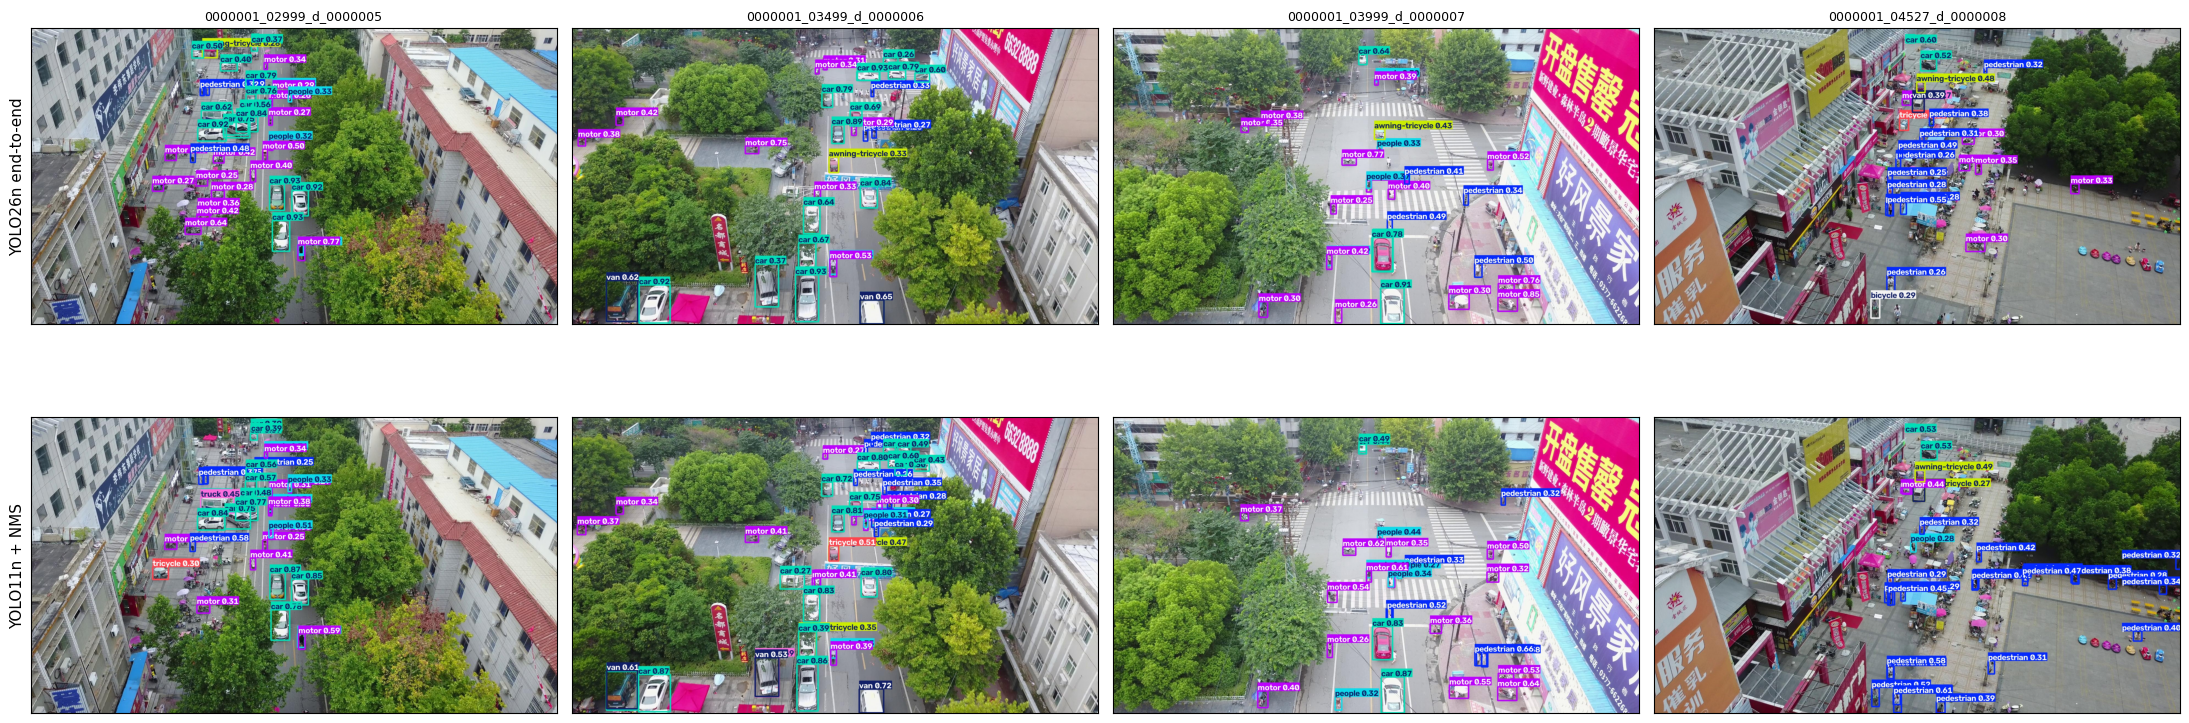

saved -> /content/drive/MyDrive/dl_final_project_yolo26/qualitative/slide11_qualitative_grid.png

SLIDE 11  boxes per image
| Boxes per image         | ..._0000005 | ..._0000006 | ..._0000007 | ..._0000008 | Recall |
|-------------------------|------------:|------------:|------------:|------------:|-------:|
| YOLO11n  before NMS     |         105 |         136 |          82 |          62 |        |
| YOLO11n  after NMS      |          36 |          43 |          30 |          32 | 33.08% |
| YOLO26n  (default head) |          41 |          32 |          27 |          24 | 33.23% |

Totals
| Over the four images    | Boxes | Recall (full split) | vs YOLO11n after NMS |
|-------------------------|------:|--------------------:|---------------------:|
| YOLO11n  before NMS     |   385 |                   - |              +173.0% |
| YOLO11n  after NMS      |   141 |              33.08% |                    - |
| YOLO26n  (default head) |   124 |              33.23% |               -12.1% 

In [44]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

counts = []
for img in val_images:
    raw = best11.predict(img, imgsz=IMGSZ, conf=0.25, iou=1.0, max_det=3000, verbose=False)[0]
    nms = best11.predict(img, imgsz=IMGSZ, conf=0.25, verbose=False)[0]
    e2e = best26.predict(img, imgsz=IMGSZ, conf=0.25, nms=False, verbose=False)[0]
    counts.append({'image': os.path.basename(img),
                   'YOLO11 before NMS': len(raw.boxes),
                   'YOLO11 after NMS':  len(nms.boxes),
                   'YOLO26 end-to-end': len(e2e.boxes)})

slide11 = pd.DataFrame(counts)
slide11.to_csv(f'{PROJECT_DIR}/slide11_box_counts.csv', index=False)

# ── slideshow table: transposed, one row per configuration ─────────────────
# NOTE on the third row's label. The slideshow calls it "YOLO26n (default
# head)". The measurement itself is nms=False (the one-to-one, NMS-free head).
#
# recall comes from exp1_new, not exp1: the counts above are measured now, so
# pairing them with the original run's recall would mix two sessions.
rec   = exp1_new.set_index('configuration')['recall']
stems = ['..._' + os.path.splitext(s)[0].rsplit('_', 1)[-1] for s in slide11.image]

ROWS11 = [('YOLO11n  before NMS',     'YOLO11 before NMS', None),
          ('YOLO11n  after NMS',      'YOLO11 after NMS',  CFG11),
          ('YOLO26n  (default head)', 'YOLO26 end-to-end', CFG26_E2E)]

slide11_deck = pd.DataFrame([{
    'Boxes per image': label,
    **{stem: int(v) for stem, v in zip(stems, slide11[col])},
    'Recall': f'{r(rec[cfg] * 100)}%' if cfg else '',
} for label, col, cfg in ROWS11])

# ── the eight images, then the table ─────────────────────────────
ROWS_IMG = [('YOLO26n end-to-end', f'{qual_dir}/yolo26'),
            ('YOLO11n + NMS',      f'{qual_dir}/yolo11')]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for r_i, (row_label, row_dir) in enumerate(ROWS_IMG):
    for c, img_path in enumerate(val_images):
        ax = axes[r_i, c]
        ax.imshow(mpimg.imread(os.path.join(row_dir, os.path.basename(img_path))))
        ax.set_xticks([]); ax.set_yticks([])
        if r_i == 0:
            ax.set_title(os.path.splitext(os.path.basename(img_path))[0], fontsize=9)
        if c == 0:
            ax.set_ylabel(row_label, fontsize=11)
fig.tight_layout()
grid_png = f'{qual_dir}/slide11_qualitative_grid.png'
fig.savefig(grid_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'saved -> {grid_png}')

table(slide11_deck, left=(0,), title='SLIDE 11  boxes per image')

# ── what the counts add up to ──────────────────────────────────────────────
_tot = {col: int(slide11[col].sum()) for _, col, _ in ROWS11}
_b11 = _tot['YOLO11 after NMS']
_b26 = _tot['YOLO26 end-to-end']

table(pd.DataFrame([{
    'Over the four images': label,
    'Boxes':               f'{_tot[col]:,}',
    'Recall (full split)':  f'{r(rec[cfg] * 100)}%' if cfg else '-',
    'vs YOLO11n after NMS': '-' if col == 'YOLO11 after NMS'
                            else f'{r((_tot[col] / _b11 - 1) * 100, 1, signed=True)}%',
} for label, col, cfg in ROWS11]), left=(0,), title='Totals')

print(f'\n{_b26} boxes vs {_b11} at '
      f'{r(rec[CFG26_E2E] * 100)}% vs {r(rec[CFG11] * 100)}% recall')
print('  -> fewer boxes at the same recall: what NMS removes is duplication,')
print('     not detections YOLO26n missed.')

## Part 6 · Slide 12 — NMS-free vs NMS on identical weights

**Claim C, test 2 of 2:** the paper says dropping NMS costs only ~0.6–0.8 mAP.

We run the same checkpoint twice, once with each head, and compare: how much accuracy the
NMS-free head gives up, and how much latency it saves. Same weights, same data, same
hardware — only the head differs.

The cell formats the two rows side by side, with the cost's interval and p-value from 2c.

In [45]:
LABEL12 = {CFG26_E2E: 'End-to-end (NMS-free)',
           CFG26_NMS: 'One-to-many (NMS)'}


def build_slide12(e):
    """Slide 12 as it renders, from any exp1-shaped frame."""
    E_ = e.set_index('configuration')
    t  = E_.loc[[CFG26_E2E, CFG26_NMS], ['mAP50-95', 'mAP50', 'precision',
                                         'recall', 'postprocess_ms',
                                         'total_ms']].reset_index()
    return pd.DataFrame([{
        'Mode (YOLO26n)': LABEL12[rw['configuration']],
        'mAP50-95':       f"{r(rw['mAP50-95'] * 100)}%",
        'mAP50':          f"{r(rw['mAP50'] * 100)}%",
        'Precision':      f"{r(rw['precision'] * 100)}%",
        'Recall':         f"{r(rw['recall'] * 100)}%",
        'Postprocess':    f"{r(rw['postprocess_ms'])} ms",
        'Total latency':  f"{r(rw['total_ms'])} ms",
        'Fused params':   f"{r(PARAMS[rw['configuration']] / 1e6)}M "
                          f"({LAYERS[rw['configuration']]} layers)",
    } for _, rw in t.iterrows()]), t


slide12_deck, slide12 = build_slide12(exp1)
slide12.to_csv(f'{PROJECT_DIR}/slide12_result2.csv', index=False)

table(slide12_deck, left=(0,), title=f'SLIDE 12  ({DATA_SOURCE})')

# ── one file, both heads ───────────────────────────────────────────────────
table(pd.DataFrame([{
    'Head':        SHORT[cfg],
    'Layers':      f'{LAYERS[cfg]:,}',
    'Params':      f'{PARAMS[cfg]:,}',
    'Checkpoint':  f'{RUN26}/weights/best.pt' if cfg != CFG11
                   else f'{RUN11}/weights/best.pt',
} for cfg in (CFG26_E2E, CFG26_NMS, CFG11)]),
    left=(0, 3), title='Model size  -- the two YOLO26n rows are the same file')

# ── what the ablation costs, and what it saves ─────────────────────────────
C    = CI.loc['YOLO26n e2e - YOLO26n+NMS']
cost = -C['delta_pts']

E_act  = exp1.set_index('configuration')
post   = E_act['postprocess_ms']
tot_ms = E_act['total_ms']
d_post = (1 - post[CFG26_E2E] / post[CFG26_NMS]) * 100
d_tot  = (1 - tot_ms[CFG26_E2E] / tot_ms[CFG26_NMS]) * 100

table(pd.DataFrame([
    {'Dropping NMS': 'accuracy cost',
     'Value':  f'{r(cost)} mAP50-95 points',
     'Detail': f"95% CI [{r(-C['ci_high'])}, {r(-C['ci_low'])}]   "
               f"p {pfmt(C['p_value'])}   "
               f"{'significant' if C['p_value'] < 0.05 else 'not significant'}"},
    {'Dropping NMS': "paper's 0.6 - 0.8 range",
     'Value':  'inside' if 0.6 <= cost <= 0.8 else 'OUTSIDE',
     'Detail': ''},
    {'Dropping NMS': 'postprocess',
     'Value':  f'{r(post[CFG26_NMS])} -> {r(post[CFG26_E2E])} ms',
     'Detail': f'{r(d_post, 1, signed=True)}%'},
    {'Dropping NMS': 'total latency',
     'Value':  f'{r(tot_ms[CFG26_NMS])} -> {r(tot_ms[CFG26_E2E])} ms',
     'Detail': f'{r(-d_tot, 1, signed=True)}%'},
]), left=(0, 1, 2), title='The ablation')


SLIDE 12  (new)
| Mode (YOLO26n)        | mAP50-95 |  mAP50 | Precision | Recall | Postprocess | Total latency |       Fused params |
|-----------------------|---------:|-------:|----------:|-------:|------------:|--------------:|-------------------:|
| End-to-end (NMS-free) |   17.21% | 31.15% |    45.10% | 33.23% |     0.21 ms |      12.09 ms | 2.38M (122 layers) |
| One-to-many (NMS)     |   17.89% | 32.10% |    44.63% | 34.58% |     1.48 ms |      12.86 ms | 2.38M (120 layers) |

Model size  -- the two YOLO26n rows are the same file
| Head          | Layers |    Params | Checkpoint                             |
|---------------|-------:|----------:|----------------------------------------|
| YOLO26n e2e   |    122 | 2,376,786 | yolo26n_visdrone_musgd/weights/best.pt |
| YOLO26n + NMS |    120 | 2,376,786 | yolo26n_visdrone_musgd/weights/best.pt |
| YOLO11n + NMS |    101 | 2,584,102 | yolo11n_visdrone_sgd/weights/best.pt   |

The ablation
| Dropping NMS            | Value         

## Part 7 - Slide 13: Result 3, the CPU speed claim

**Claim D:** *"up to 43% faster CPU inference"* (paper, p. 9).


Comparison between **YOLO26n + NMS vs YOLO11n + NMS on
`inference_ms`**: NMS runs on both sides and sits outside the measurement, leaving the
forward pass as the only variable.

**7a measures, 7b reports.** With `DATA_SOURCE = 'original'` you can skip 7a entirely.
With `DATA_SOURCE = 'new'` you must run it - 7b has nothing to read otherwise

### 7a · CPU timing
Exports both models to ONNX and times them on the CPU over five passes of the validation
split.

In [17]:
# --- 7a. CPU timing (~11 min). Required only for DATA_SOURCE = 'new'. -----
!pip install -q onnx onnxruntime onnxslim

REPEATS = 3
CONFIGS = [(M26, W26, {'nms': None}),      # one-to-many head, as on the GPU
           (M11, W11, {})]

if DATA_SOURCE != 'new':
    print(f"DATA_SOURCE = {DATA_SOURCE!r} -- skipping 7a. "
          f'7b will use the {ORIG_LABEL}.')
else:
    models = {}
    for tag, w, kw in CONFIGS:
        print(f'exporting {tag} ...')
        models[tag] = YOLO(YOLO(w).export(format='onnx', imgsz=IMGSZ,
                                          simplify=True, **kw),
                           task='detect')

    # INTERLEAVED: 26, 11, 26, 11, ... rather than in blocks.  A shared cloud
    # CPU drifts over minutes; measuring in blocks folds that drift entirely
    # into the difference between the models -- the within-model spread stayed
    # near 2% while the ratio moved 3.6 points between sessions.  Interleaving
    # cancels it.
    raw, cpu_maps = [], {}
    for k in range(REPEATS):
        for tag, _, _ in CONFIGS:
            res = models[tag].val(data=DATA, imgsz=IMGSZ, split='val', batch=1,
                                  device='cpu', max_det=MAX_DET, verbose=False)
            raw.append({'rep': k + 1, 'model': tag,
                        **{key: float(res.speed[key]) for key in KEYS}})
            cpu_maps[tag] = float(res.box.map)
            print(f'  rep {k+1}/{REPEATS}  {tag:16}  ' +
                  '  '.join(f'{key} {raw[-1][key]:6.2f}' for key in KEYS))

    raw_df = pd.DataFrame(raw)
    raw_df.to_csv(f'{PROJECT_DIR}/slide13_cpu_raw.csv', index=False)
    pd.DataFrame([{'model': k, 'mAP50-95': v} for k, v in cpu_maps.items()]).to_csv(
        f'{PROJECT_DIR}/slide13_cpu_map.csv', index=False)
    print(f'\nSaved {len(raw_df)} measurements. 7b reports; it does not re-time.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 26.6 MB/s eta 0:00:00
exporting YOLO26n + NMS ...
Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/dl_final_project_yolo26/yolo26n_visdrone_musgd/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.1 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.7s, saved as '/content/drive/MyDrive/dl_final_project_yolo26/yolo26n_visdrone_musgd/weights/best.onnx' (9.3 MB)

### 7b ·The CPU result
Takes the median of 7a's five repeats, reports the forward pass for each model
and the saving between them, and measures it against the paper's ceiling of "up to 43%".


In [47]:
FRAMING     = 'reduction'
PAPER_SPEED = 43.0          # "up to 43% faster CPU inference" (paper, p. 9)

slide13_orig = pd.DataFrame([{'model': k, **v} for k, v in SNAP_CPU.items()])

raw_path   = f'{PROJECT_DIR}/slide13_cpu_raw.csv'
N_REPS_NEW = None
_raw       = None
if os.path.exists(raw_path):
    _raw       = pd.read_csv(raw_path)
    N_REPS_NEW = int(_raw.rep.max())
    g   = _raw.groupby('model')
    mp  = {}
    map_path = f'{PROJECT_DIR}/slide13_cpu_map.csv'
    if os.path.exists(map_path):
        mp = dict(pd.read_csv(map_path).values)
    # median over repeats: CPU timing has a right tail, and one throttled
    # repeat moves a mean but not a median.  spread is the full range.
    slide13_new = pd.DataFrame([{
        'model':          t,
        'mAP50-95':       float(mp.get(t, np.nan)),
        'inference_ms':   float(g.get_group(t).inference.median()),
        'postprocess_ms': float(g.get_group(t).postprocess.median()),
        'total_ms':       float(g.get_group(t)[list(KEYS)].sum(1).median()),
        'spread_ms':      float(g.get_group(t).inference.max()
                                - g.get_group(t).inference.min()),
    } for t in (M26, M11)])
else:
    slide13_new = None
    if DATA_SOURCE == 'new':
        raise FileNotFoundError(
            "DATA_SOURCE = 'new' but slide13_cpu_raw.csv does not exist. Run 7a first.")

slide13 = slide13_new.copy() if DATA_SOURCE == 'new' else slide13_orig.copy()


def cpu_stats(s):
    S_ = s.set_index('model')['inference_ms']
    base, i26 = float(S_[M11]), float(S_[M26])
    return base, i26, base - i26, (base - i26) / base * 100, (base / i26 - 1) * 100


def build_slide13(s):
    """Slide 13 exactly as it renders, from any slide13-shaped frame."""
    base = float(s.set_index('model')['inference_ms'][M11])

    def vs(rw):
        if rw['model'] == M11:                       # keyed by model, not value
            return 'baseline'
        t = float(rw['inference_ms'])
        return (f'{r((1 - t / base) * 100, 1)}%' if FRAMING == 'reduction'
                else f'+{r((base / t - 1) * 100, 1)}%')

    return pd.DataFrame([{
        'Model':                rw['model'],
        'Runtime':              'ONNX / CPU',
        'mAP50-95':             f"{r(rw['mAP50-95'] * 100)}%" if pd.notna(rw['mAP50-95']) else '-',
        'Inference':            f"{r(rw['inference_ms'])} ms",
        'Postprocess':          f"{r(rw['postprocess_ms'])} ms",
        'Total':                f"{r(rw['total_ms'])} ms",
        'vs YOLO11n Inference': vs(rw),
        'spread':               f"{r(rw['spread_ms'])} ms",
    } for _, rw in s.iterrows()])


slide13_deck = build_slide13(slide13)
slide13.to_csv(f'{PROJECT_DIR}/slide13_cpu_onnx.csv', index=False)

base_inf, inf26, saved, reduction, speedup = cpu_stats(slide13)

# the headline figure follows FRAMING, so the table and the text never disagree
shown, framing_label = ((reduction, 'time reduction') if FRAMING == 'reduction'
                        else (speedup, 'speed-up'))

table(slide13_deck, left=(0, 1),
      title=f'SLIDE 13  ({DATA_SOURCE} | framing: {FRAMING})')

print('\nForward pass (inference only -- NMS runs on both sides, outside the measurement)')
print(f'  {r(base_inf)} -> {r(inf26)} ms      saved {r(saved)} ms')
print(f"  measured {framing_label}  {r(shown, 1)}%      paper's claim  {PAPER_SPEED}%")
print(f'  -> {r(shown, 1)}% {"<" if shown < PAPER_SPEED else ">="} {PAPER_SPEED}%: '
      f'the claim does {"NOT " if shown > PAPER_SPEED else ""}reproduce on this '
      f'machine ({os.cpu_count()} vCPUs).')

# ── per-repeat, so the gap can be weighed against the noise ────────────────
# Interleaved in 7a (26, 11, 26, 11 ...), so drift is shared rather than
# folded into the difference between the models.
if _raw is not None:
    _p  = _raw.pivot_table(index='rep', columns='model', values='inference')
    _pr = (1 - _p[M26] / _p[M11]) * 100
    table(pd.DataFrame([{
        'rep':       f'{int(k)}',
        'YOLO11n':   f'{r(_p.loc[k, M11])} ms',
        'YOLO26n':   f'{r(_p.loc[k, M26])} ms',
        'reduction': f'{r(_pr[k], 1)}%',
    } for k in _p.index]), left=(0,), title='Per-repeat forward pass')
    print(f'  median {r(_pr.median(), 1)}%   range {r(_pr.min(), 1)}% - '
          f'{r(_pr.max(), 1)}%   (n = {N_REPS_NEW})')

if G11 > 0 and G26 > 0:
    flops_cut = (1 - G26 / G11) * 100
    print(f'\nFLOPs {G11:.1f} -> {G26:.1f} (-{r(flops_cut, 1)}%): the forward pass '
          + (f'shrinks {r(reduction / flops_cut, 1)}x more than FLOPs alone predict.'
             if flops_cut > 0 else 'cannot be compared -- the two report equal FLOPs.'))
else:
    print('\nFLOPs unavailable for at least one model -- skipping the FLOPs comparison.')

if slide13_new is not None:
    print('\nBoth frames stay in memory (slide13_new, slide13_orig). '
          'Part 8 reports the drift.')


SLIDE 13  (new | framing: reduction)
| Model         | Runtime    | mAP50-95 | Inference | Postprocess |    Total | vs YOLO11n Inference |  spread |
|---------------|------------|---------:|----------:|------------:|---------:|---------------------:|--------:|
| YOLO26n + NMS | ONNX / CPU |   17.94% |  27.68 ms |    40.51 ms | 70.78 ms |                32.8% | 2.53 ms |
| YOLO11n + NMS | ONNX / CPU |   17.40% |  41.19 ms |    42.26 ms | 85.84 ms |             baseline | 2.38 ms |

Forward pass (inference only -- NMS runs on both sides, outside the measurement)
  41.19 -> 27.68 ms      saved 13.51 ms
  measured time reduction  32.8%      paper's claim  43.0%
  -> 32.8% < 43.0%: the claim does reproduce on this machine (12 vCPUs).

Per-repeat forward pass
| rep |  YOLO11n |  YOLO26n | reduction |
|-----|---------:|---------:|----------:|
| 1   | 41.71 ms | 26.19 ms |     37.2% |
| 2   | 41.19 ms | 27.44 ms |     33.4% |
| 3   | 40.21 ms | 28.71 ms |     28.6% |
| 4   | 41.06 ms | 27.68 

## Part 8 - Summary

Today's run beside the original one, value by value — latency, model size, and every figure
the slides quote, including all four claims.

In [48]:
print('=' * 100)
print(f'SUMMARY   --   DATA_SOURCE = {DATA_SOURCE!r}   |   VERBOSITY = {VERBOSITY!r}')
print(f'          --   {ORIG_LABEL if DATA_SOURCE == "original" else NEW_LABEL}')
print('=' * 100)


def drift_table(title, rows, unit='ms', nd=2):
    """rows: (label, today, original).  original / today / diff / change.
    Lists only rows over DRIFT_TOL unless VERBOSITY == 'full'."""
    over  = [t for t in rows if abs(t[1] / t[2] - 1) * 100 > DRIFT_TOL]
    shown = rows if VERBOSITY == 'full' else over
    if shown:
        table(pd.DataFrame([{
            'Measurement':  label,
            'original run': f'{r(orig, nd)} {unit}',
            'today':        f'{r(now, nd)} {unit}',
            'diff':         f'{r(now - orig, nd, signed=True)} {unit}',
            'change':       f'{r((now / orig - 1) * 100, 1, signed=True)}%',
        } for label, now, orig in shown]),
            left=(0,), title=f'{title}  --  today vs {ORIG_LABEL}')
    label_max, n_max, o_max = max(rows, key=lambda t: abs(t[1] / t[2] - 1))
    print(f'{title:6} {len(over)}/{len(rows)} rows over {DRIFT_TOL:.0f}%, '
          f'largest {r(abs(n_max / o_max - 1) * 100, 1)}% '
          f'({r(n_max - o_max, nd, signed=True)} {unit} on {label_max})')


# ══ LATENCY DRIFT ═════════════════════════════════════════════════════════
print('\nLATENCY DRIFT')

drift_table('GPU', [
    (f'{SHORT[cfg]} {col[:-3]}',
     float(exp1_new.loc[exp1_new.configuration == cfg, col].iloc[0]), frozen)
    for cfg, snap in SNAP_GPU.items() for col, frozen in snap.items()])

if slide13_new is not None:
    _cn = slide13_new.set_index('model')
    drift_table('CPU', [
        (f'{tag} {col[:-3]}', float(_cn.loc[tag, col]), SNAP_CPU[tag][col])
        for tag in (M26, M11)
        for col in ('inference_ms', 'postprocess_ms', 'total_ms')])
else:
    print('CPU    not measured this session (7a was not run)')

# ══ MODEL SIZE ════════════════════════════════════════════════════════════
# Not latency -- identical every session unless the checkpoint, the head
# selection or the Ultralytics version moved.
CHECKS = [(f'{SHORT[cfg]} {name}', SNAP_SIZE[cfg][k], SIZE_NEW[cfg][k], fmt, tol)
          for cfg in (CFG26_E2E, CFG26_NMS, CFG11)
          for k, name, fmt, tol in ((0, 'layers', '{:,}', 0),
                                    (1, 'params', '{:,}', 0),
                                    (2, 'GFLOPs', '{:.1f}', 0.05))]
bad = [c for c in CHECKS if abs(c[2] - c[1]) > c[4]]

if bad or VERBOSITY == 'full':
    table(pd.DataFrame([{
        'Value':        label,
        'original run': fmt.format(orig),
        'today':        fmt.format(now),
        'diff':         '0' if now == orig else fmt.format(now - orig),
        'status':       'ok' if abs(now - orig) <= tol else 'DIFFERS',
    } for label, orig, now, fmt, tol in (CHECKS if VERBOSITY == 'full' else bad)]),
        left=(0,), title=f'MODEL SIZE  --  today vs {ORIG_LABEL}')
print(f'\nMODEL SIZE   {len(CHECKS) - len(bad)}/{len(CHECKS)} values match the '
      f'original run' + ('' if not bad else '   <-- check the slideshow'))

# ══ SLIDE 12 -- the ablation: what it costs, what it saves ════════════════
_n  = exp1_new.set_index('configuration')
_oC = SNAP_CLAIMS['C']

table(pd.DataFrame([{
    'Figure':       label,
    'original run': f'{r(o, nd)}{unit and " " + unit}',
    'today':        f'{r(n, nd)}{unit and " " + unit}',
    'diff':         f'{r(n - o, nd, signed=True)}',
} for label, o, n, nd, unit in [
    ('mAP50-95 cost (e2e - NMS)', _oC['cost'],   cost,          2, 'mAP'),
    ('   95% CI low',             _oC['ci'][0], -C['ci_high'],  2, 'mAP'),
    ('   95% CI high',            _oC['ci'][1], -C['ci_low'],   2, 'mAP'),
    ('   p-value',                _oC['p'],      C['p_value'],  3, ''),
]]), left=(0,), title='SLIDE 12  accuracy cost of dropping NMS')

_po_nms, _po_e2e = (SNAP_GPU[CFG26_NMS]['postprocess_ms'],
                    SNAP_GPU[CFG26_E2E]['postprocess_ms'])
_pn_nms, _pn_e2e = (float(_n.loc[CFG26_NMS, 'postprocess_ms']),
                    float(_n.loc[CFG26_E2E, 'postprocess_ms']))
_to_nms, _to_e2e = (SNAP_GPU[CFG26_NMS]['total_ms'], SNAP_GPU[CFG26_E2E]['total_ms'])
_tn_nms, _tn_e2e = (float(_n.loc[CFG26_NMS, 'total_ms']),
                    float(_n.loc[CFG26_E2E, 'total_ms']))
_share_o = (1 - _po_e2e / _po_nms) * 100
_share_n = (1 - _pn_e2e / _pn_nms) * 100

table(pd.DataFrame(
    [{'Figure':       label,
      'original run': f'{r(o)} ms',
      'today':        f'{r(n)} ms',
      'diff':         f'{r(n - o, signed=True)} ms'}
     for label, o, n in [
         ('postprocess    one-to-many', _po_nms, _pn_nms),
         ('postprocess    end-to-end',  _po_e2e, _pn_e2e),
         ('postprocess    saved',       _po_nms - _po_e2e, _pn_nms - _pn_e2e),
         ('total latency  one-to-many', _to_nms, _tn_nms),
         ('total latency  end-to-end',  _to_e2e, _tn_e2e),
         ('total latency  saved',       _to_nms - _to_e2e, _tn_nms - _tn_e2e)]]
    + [{'Figure':       'postprocess    saved, as a share',
        'original run': f'{r(_share_o, 1)}%',
        'today':        f'{r(_share_n, 1)}%',
        'diff':         f'{r(_share_n - _share_o, 1, signed=True)} pts'}]),
    left=(0,), title='SLIDE 12  latency the NMS-free head saves')

# ══ SLIDE 13 -- the CPU forward pass ══════════════════════════════════════
# Accuracy is identical on both runs (same ONNX graphs, same images), so only
# the inference times and the ratio between them are worth comparing.
red_o = red_n = None
if slide13_new is not None:
    _so = slide13_orig.set_index('model')['inference_ms']
    _sn = slide13_new.set_index('model')['inference_ms']
    _bo, _io = float(_so[M11]), float(_so[M26])
    _bn, _in = float(_sn[M11]), float(_sn[M26])
    red_o, red_n = (_bo - _io) / _bo * 100, (_bn - _in) / _bn * 100

    table(pd.DataFrame([{
        'Figure':       label,
        'original run': f'{r(o, nd)}{unit and " " + unit}',
        'today':        f'{r(n, nd)}{unit and " " + unit}',
        'diff':         f'{r(n - o, nd, signed=True)}{unit and " " + unit}',
    } for label, o, n, nd, unit in [
        ('inference  YOLO11n', _bo, _bn, 2, 'ms'),
        ('inference  YOLO26n', _io, _in, 2, 'ms'),
        ('saved',              _bo - _io, _bn - _in, 2, 'ms'),
        ('vs YOLO11n  (the column on the slide)', red_o, red_n, 1, '%'),
    ]]), left=(0,), title='SLIDE 13  CPU forward pass')

# ── both runs' tables in full, on demand ───────────────────────────────────
if VERBOSITY == 'full':
    for title, orig, new in (('SLIDE 9  Result 1', build_slide9(exp1_orig),
                                                   build_slide9(exp1_new)),
                             ('SLIDE 12 Result 2', build_slide12(exp1_orig)[0],
                                                   build_slide12(exp1_new)[0])):
        table(orig, left=(0,), title=f'{title}   [1] {ORIG_LABEL}')
        table(new,  left=(0,), title=f'{title}   [2] {NEW_LABEL}')
    if slide13_new is not None:
        table(build_slide13(slide13_orig), left=(0, 1),
              title=f'SLIDE 13 Result 3   [1] {ORIG_LABEL}')
        table(build_slide13(slide13_new), left=(0, 1),
              title=f'SLIDE 13 Result 3   [2] {NEW_LABEL}')

# ══ SLIDE 14 -- every figure quoted in the prose, both runs ═══════════════
# The bootstrap in 2c always runs on today's predictions, so the 'today'
# column is live even when DATA_SOURCE = 'original'.  These are deterministic
# quantities: they should agree to about 0.01 point, and a larger move means
# something changed in the checkpoint or the evaluator, not in the hardware.
print('\n' + '=' * 100)
print('SLIDE 14  -- every figure quoted in the prose, original run vs today')
print('=' * 100)

A   = CI.loc['ALL: YOLO26n+NMS - YOLO11n+NMS']
Ae  = CI.loc['YOLO26n e2e - YOLO11n+NMS']
obs = lambda c: float(slide10.loc[slide10['class'] == c, 'delta_pts'].iloc[0])

claim_rows = [
    ('A  mAP gain',      'architectural gap',  SNAP_CLAIMS['A']['delta'],      A['delta_pts'],    2, 'pts'),
    ('',                 'p-value',            SNAP_CLAIMS['A']['p'],          A['p_value'],      3, ''),
    ('   deployment',    'deployment gap',     SNAP_CLAIMS['dep']['delta'],    Ae['delta_pts'],   2, 'pts'),
    ('',                 'p-value',            SNAP_CLAIMS['dep']['p'],        Ae['p_value'],     3, ''),
    ('B  small objects', 'people AP gain',     SNAP_CLAIMS['B']['people'],     obs('people'),     2, 'pts'),
    ('',                 'pedestrian AP gain', SNAP_CLAIMS['B']['pedestrian'], obs('pedestrian'), 2, 'pts'),
    ('',                 'motor AP gain',      SNAP_CLAIMS['B']['motor'],      obs('motor'),      2, 'pts'),
    ('C  NMS-free cost', 'cost',               SNAP_CLAIMS['C']['cost'],       cost,              2, 'mAP'),
    ('',                 'p-value',            SNAP_CLAIMS['C']['p'],          C['p_value'],      3, ''),
]
if red_o is not None:
    claim_rows.append(('D  CPU forward pass', 'time reduction', red_o, red_n, 1, '%'))

table(pd.DataFrame([{
    'Claim':        claim,
    'Figure':       figure,
    'original run': f'{r(o, nd)}{unit and " " + unit}',
    'today':        f'{r(n, nd)}{unit and " " + unit}',
    'diff':         f'{r(n - o, nd, signed=True)}',
} for claim, figure, o, n, nd, unit in claim_rows]), left=(0, 1))

table(pd.DataFrame([
    {'Claim': 'A  mAP gain', 'Verdict today':
     f"{r(A['delta_pts'], signed=True)} mAP, p {pfmt(A['p_value'])} -- "
     f"{'significant' if A['significant'] == 'yes' else 'not significant'}"},
    {'Claim': 'B  small objects', 'Verdict today':
     f"{len(sig)} classes clear zero: {', '.join(sig)}"},
    {'Claim': 'C  NMS-free cost', 'Verdict today':
     f"{r(cost)} mAP, p {pfmt(C['p_value'])} -- "
     f"paper's 0.6-0.8 range: {'inside' if 0.6 <= cost <= 0.8 else 'OUTSIDE'}"},
    {'Claim': 'D  CPU forward pass', 'Verdict today':
     f'{r(reduction, 1)}% less time ({r(base_inf)} -> {r(inf26)} ms), '
     f'against a ceiling of up to {PAPER_SPEED}%'},
]), left=(0, 1))

print('\nWhy Claim A did not reproduce')
print('  paper   Objects365 150 epochs + COCO 245 epochs (nano)   [paper, sec. 4.2]')
print(f'  ours    VisDrone {EPOCHS} epochs from COCO-pretrained weights')

held = sum([len(sig) > 0,
            0.6 <= cost <= 0.8 and C['significant'] == 'yes',
            reduction > 0])
print(f'\n  -> {held} of the 4 claims held (B, C, D); A did not reproduce.')

# ══ SLIDES 15-16 ══════════════════════════════════════════════════════════
print('\n' + '=' * 100)
print('SLIDES 15-16  -- verification, original run vs today')
print('=' * 100)

try:
    import torch
    _gpu_now = torch.cuda.get_device_name(0)
except Exception:
    _gpu_now = 'no CUDA device'

_settings = f'epochs {EPOCHS}, imgsz {IMGSZ}, batch {BATCH}, seed {SEED}'
_optim    = 'MuSGD (YOLO26n) / SGD (YOLO11n)'

table(pd.DataFrame([
    {'Slide 15  environment': 'GPU',
     'original run': SNAP_ENV['gpu'],               'today': _gpu_now},
    {'Slide 15  environment': 'vCPUs',
     'original run': f"{SNAP_ENV['vcpus']}",        'today': f'{os.cpu_count()}'},
    {'Slide 15  environment': 'RAM',
     'original run': f"{SNAP_ENV['ram_gb']:.1f} GB",
     'today':        f'{psutil.virtual_memory().total / 1e9:.1f} GB'},
    {'Slide 15  environment': 'ultralytics',
     'original run': SNAP_ENV['ultralytics'],       'today': ultralytics.__version__},
    {'Slide 15  environment': 'optimizers',
     'original run': _optim,                        'today': _optim},
    {'Slide 15  environment': 'run settings',
     'original run': _settings,                     'today': _settings},
]), left=(0, 1, 2))

table(pd.DataFrame([
    {'Slide 16  conclusion': 'postprocess',
     'original run': f'{r(_po_nms)} -> {r(_po_e2e)} ms',
     'today':        f'{r(_pn_nms)} -> {r(_pn_e2e)} ms'},
    {'Slide 16  conclusion': 'cost of NMS-free',
     'original run': f"{r(_oC['cost'])} mAP",
     'today':        f'{r(cost)} mAP'},
    {'Slide 16  conclusion': 'compute',
     'original run': f'{SNAP_SIZE[CFG26_NMS][2]:.1f} vs {SNAP_SIZE[CFG11][2]:.1f} GFLOPs '
                     f'({r((1 - SNAP_SIZE[CFG26_NMS][2] / SNAP_SIZE[CFG11][2]) * 100, 0)}% less)',
     'today':        f'{r(G26, 1)} vs {r(G11, 1)} GFLOPs '
                     f'({r((1 - G26 / G11) * 100, 0)}% less)'},
    {'Slide 16  conclusion': 'overall gain',
     'original run': f"{r(SNAP_CLAIMS['A']['delta'], signed=True)} mAP "
                     f"({'yes' if SNAP_CLAIMS['A']['p'] < 0.05 else 'no'})",
     'today':        f"{r(A['delta_pts'], signed=True)} mAP ({A['significant']})"},
    {'Slide 16  conclusion': 'small objects',
     'original run': f"{len(SNAP_CLAIMS['B'])} classes clear zero",
     'today':        f'{len(sig)} classes clear zero'},
]), left=(0, 1, 2))

SUMMARY   --   DATA_SOURCE = 'new'   |   VERBOSITY = 'compact'
          --   new run (today)

LATENCY DRIFT

GPU  --  today vs original run (2026-09-02)
| Measurement               | original run |    today |     diff | change |
|---------------------------|-------------:|---------:|---------:|-------:|
| YOLO26n + NMS inference   |     11.97 ms | 10.70 ms | -1.27 ms | -10.6% |
| YOLO26n + NMS postprocess |      1.75 ms |  1.48 ms | -0.27 ms | -15.4% |
| YOLO26n + NMS total       |     14.46 ms | 12.86 ms | -1.60 ms | -11.0% |
| YOLO26n e2e inference     |     12.49 ms | 11.23 ms | -1.26 ms | -10.1% |
| YOLO26n e2e postprocess   |      0.25 ms |  0.21 ms | -0.04 ms | -17.3% |
| YOLO26n e2e total         |     13.43 ms | 12.09 ms | -1.34 ms | -10.0% |
| YOLO11n + NMS inference   |     10.46 ms |  9.63 ms | -0.83 ms |  -7.9% |
| YOLO11n + NMS postprocess |      1.69 ms |  1.52 ms | -0.17 ms | -10.3% |
| YOLO11n + NMS total       |     12.87 ms | 11.89 ms | -0.98 ms |  -7.6% |
GPU    9/9